<a href="https://colab.research.google.com/github/caramos84/IBM-AI-Engineering-Course/blob/main/LinearRegression_Sample02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal simple: horas de estudio vs nota final

En este ejercicio vamos a construir un modelo de **regresión lineal simple** para predecir la **nota final** de un estudiante usando como variable de entrada las **horas de estudio**.

La idea es seguir la siguiente estructura:

1. Importar librerías
2. Crear un dataset sencillo
3. Explorar los datos
4. Visualizar la relación entre variables
5. Entrenar un modelo de regresión lineal
6. Evaluarlo con métricas como **MSE**
7. Interpretar la recta obtenida

En este caso:

- **X** = horas de estudio
- **y** = nota final

In [3]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Crear un dataset simple
data = {
    "Horas_Estudio": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Nota_Final":    [52, 55, 61, 63, 68, 72, 74, 79, 83, 88]
}

df = pd.DataFrame(data)

# Ver las primeras filas
df.head()

,Horas_Estudio,Nota_Final
0,1,52
1,2,55
2,3,61
3,4,63
4,5,68


## Exploración básica de los datos

Antes de entrenar un modelo, es importante revisar el dataset.

Vamos a usar algunas funciones de `pandas` para:

- ver una muestra de los datos
- conocer estadísticas básicas
- entender el tamaño del conjunto de datos

Esto ayuda a verificar que las columnas tengan sentido y que no haya errores evidentes.

In [4]:
# Ver una muestra aleatoria de los datos
df.sample(5)

,Horas_Estudio,Nota_Final
9,10,88
6,7,74
4,5,68
3,4,63
7,8,79


In [5]:
# Ver estadísticas descriptivas
df.describe()

,Horas_Estudio,Nota_Final
count,10.00000,10.000000
mean,5.50000,69.500000
std,3.02765,11.900047
min,1.00000,52.000000
25%,3.25000,61.500000
50%,5.50000,70.000000
75%,7.75000,77.750000
max,10.00000,88.000000


In [6]:
# Ver la forma del dataset: filas y columnas
df.shape

(10, 2)

## Visualización de los datos

Ahora vamos a graficar los datos para entender mejor su comportamiento.

Usaremos dos tipos de visualización:

- **Histogramas**: para ver cómo se distribuyen los valores de cada variable.
- **Gráfico de dispersión (scatter plot)**: para observar la relación entre las horas de estudio y la nota final.

El gráfico de dispersión es especialmente importante en regresión lineal, porque nos permite ver si los puntos siguen una tendencia aproximadamente lineal.

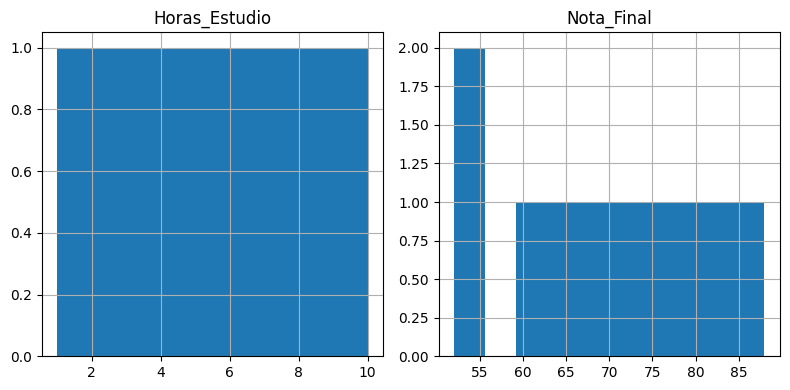

In [7]:
# Histogramas de las variables
df.hist(figsize=(8, 4))
plt.tight_layout()
plt.show()

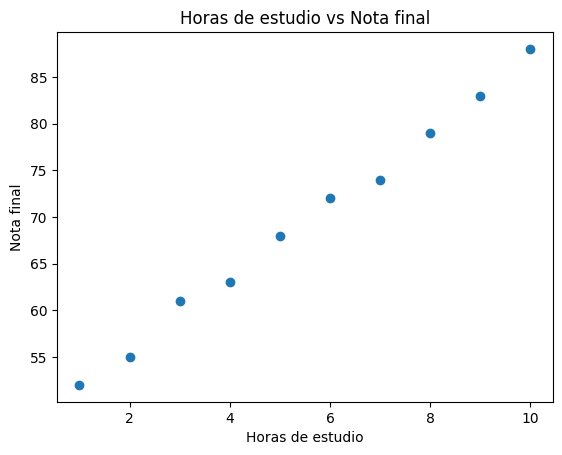

In [8]:
# Gráfico de dispersión
plt.scatter(df["Horas_Estudio"], df["Nota_Final"])
plt.xlabel("Horas de estudio")
plt.ylabel("Nota final")
plt.title("Horas de estudio vs Nota final")
plt.show()

## Definir variables: X e y

En regresión lineal, normalmente se trabaja con:

- **X**: la variable de entrada o variable independiente
- **y**: la variable objetivo o variable dependiente

En este ejemplo:

- **X = Horas_Estudio**
- **y = Nota_Final**

Esto significa que queremos predecir la nota final de un estudiante a partir de sus horas de estudio.

In [9]:
# Definir la variable de entrada (X) y la variable objetivo (y)
X = df["Horas_Estudio"].values
y = df["Nota_Final"].values

print("X:", X)
print("y:", y)

X: [ 1  2  3  4  5  6  7  8  9 10]
y: [52 55 61 63 68 72 74 79 83 88]


## Dividir los datos en entrenamiento y prueba

Antes de entrenar el modelo, vamos a dividir el dataset en dos partes:

- **Conjunto de entrenamiento**: se usa para que el modelo aprenda la relación entre las variables.
- **Conjunto de prueba**: se usa para evaluar qué tan bien predice el modelo con datos que no vio antes.

En este caso usaremos:

- **80%** de los datos para entrenamiento
- **20%** de los datos para prueba

Esto es una práctica común en machine learning, porque permite comprobar si el modelo generaliza bien.

In [10]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train)
print("X_test:", X_test)
print("y_train:", y_train)
print("y_test:", y_test)

X_train: [ 6  1  8  3 10  5  4  7]
X_test: [9 2]
y_train: [72 52 79 61 88 68 63 74]
y_test: [83 55]


## Crear y entrenar el modelo de regresión lineal

Ahora vamos a crear un modelo de **regresión lineal** usando `scikit-learn`.

Luego lo vamos a entrenar con los datos de entrenamiento.

Cuando usamos `LinearRegression()`, el modelo busca la recta que mejor se ajusta a los datos.  
Esa recta se calcula usando la lógica de **Ordinary Least Squares (OLS)**.

La idea de OLS es encontrar la línea que minimiza la suma de los errores al cuadrado entre:

- los valores reales
- los valores predichos por la recta

In [11]:
# Crear el modelo de regresión lineal
regressor = linear_model.LinearRegression()

# Entrenar el modelo
regressor.fit(X_train.reshape(-1, 1), y_train)

print("Modelo entrenado")

Modelo entrenado


## Ver la pendiente y el intercepto del modelo

Una vez entrenado el modelo, podemos consultar los dos valores principales de la recta:

- **coeficiente**: la pendiente de la recta
- **intercepto**: el valor donde la recta cruza el eje Y

La ecuación general de una regresión lineal simple es:

**y = mx + b**

donde:

- **m** es la pendiente
- **b** es el intercepto

En este ejercicio, eso nos permitirá interpretar cuánto cambia la nota final cuando aumenta una hora de estudio.

In [12]:
# Ver la pendiente y el intercepto
print("Pendiente (coeficiente):", regressor.coef_[0])
print("Intercepto:", regressor.intercept_)

Pendiente (coeficiente): 3.887931034482759
Intercepto: 48.241379310344826


In [13]:
# Mostrar la ecuación de la recta de forma legible
m = regressor.coef_[0]
b = regressor.intercept_

print(f"Ecuación del modelo: y = {m:.2f}x + {b:.2f}")

Ecuación del modelo: y = 3.89x + 48.24


## Visualizar la recta de regresión sobre los datos de entrenamiento

Ahora vamos a graficar:

- los datos reales del conjunto de entrenamiento
- la recta aprendida por el modelo

Esto nos permite ver de forma visual qué tan bien se ajusta la regresión lineal a los datos.

Si la relación entre las variables es aproximadamente lineal, la recta debería seguir la tendencia general de los puntos.

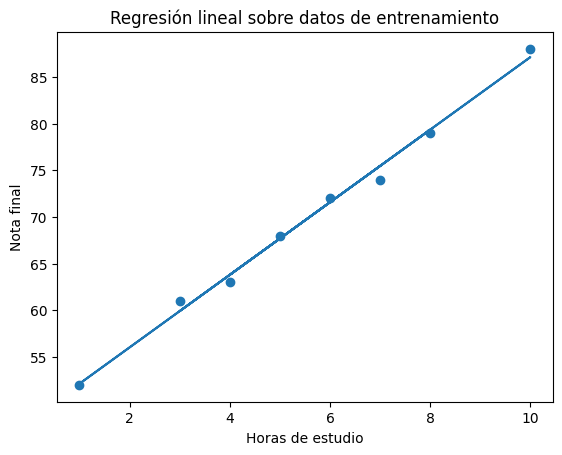

In [14]:
# Graficar los datos de entrenamiento
plt.scatter(X_train, y_train)
plt.xlabel("Horas de estudio")
plt.ylabel("Nota final")
plt.title("Regresión lineal sobre datos de entrenamiento")

# Graficar la recta de regresión
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)))

plt.show()

## Hacer predicciones y evaluar el modelo

Ahora vamos a usar el modelo entrenado para predecir las notas del conjunto de prueba.

Después compararemos:

- los valores reales
- los valores predichos

Y calcularemos algunas métricas de evaluación:

- **MAE (Mean Absolute Error)**: error absoluto promedio
- **MSE (Mean Squared Error)**: error cuadrático promedio
- **RMSE (Root Mean Squared Error)**: raíz del error cuadrático promedio
- **R²**: proporción de la variación explicada por el modelo

En particular, el **MSE** es importante porque está directamente relacionado con la lógica de **Ordinary Least Squares (OLS)**.

OLS busca la recta que minimiza los errores al cuadrado, y el MSE mide justamente el promedio de esos errores cuadrados.

In [16]:
# Hacer predicciones sobre el conjunto de prueba
y_pred = regressor.predict(X_test.reshape(-1, 1))

print("Valores reales:     ", y_test)
print("Valores predichos:  ", y_pred)

Valores reales:      [83 55]
Valores predichos:   [83.23275862 56.01724138]


In [17]:
# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  0.62
MSE:  0.54
RMSE: 0.74
R²:   1.00


In [18]:
# Comparar resultados en una tabla
results = pd.DataFrame({
    "Horas_Estudio": X_test,
    "Nota_Real": y_test,
    "Nota_Predicha": y_pred
})

results

,Horas_Estudio,Nota_Real,Nota_Predicha
0,9,83,83.232759
1,2,55,56.017241


In [19]:
# Mostrar una interpretación final automática
print(f"Ecuación del modelo: y = {m:.2f}x + {b:.2f}")
print(f"MSE del modelo: {mse:.2f}")
print(f"R² del modelo: {r2:.2f}")

print("\nInterpretación:")
print(f"- Por cada hora adicional de estudio, la nota sube aproximadamente {m:.2f} puntos.")
print(f"- Si un estudiante estudia 0 horas, el modelo estima una nota de {b:.2f}.")
print("- El modelo fue entrenado usando Ordinary Least Squares (OLS),")
print("  que busca la recta que minimiza la suma de los errores al cuadrado.")
print(f"- El MSE de {mse:.2f} resume el tamaño promedio de esos errores al cuadrado.")

Ecuación del modelo: y = 3.89x + 48.24
MSE del modelo: 0.54
R² del modelo: 1.00

Interpretación:
- Por cada hora adicional de estudio, la nota sube aproximadamente 3.89 puntos.
- Si un estudiante estudia 0 horas, el modelo estima una nota de 48.24.
- El modelo fue entrenado usando Ordinary Least Squares (OLS),
  que busca la recta que minimiza la suma de los errores al cuadrado.
- El MSE de 0.54 resume el tamaño promedio de esos errores al cuadrado.


## Estimar cuántas horas se necesitan para alcanzar una nota objetivo

Una vez entrenado el modelo, también podemos usar la ecuación de la recta al revés.

Si la regresión lineal tiene la forma:

**y = mx + b**

y queremos saber cuántas horas de estudio se necesitan para obtener una nota específica, podemos despejar **x**:

**x = (y - b) / m**

En este caso, vamos a estimar cuántas horas de estudio serían necesarias para alcanzar una **nota de 100**.

Es importante recordar que esto es una **estimación basada en la tendencia del modelo**.  
Si la nota objetivo está por fuera del rango observado en los datos, entonces el cálculo se considera una **extrapolación**.

In [20]:
# Estimar cuántas horas se necesitan para alcanzar una nota de 100
nota_objetivo = 100
horas_para_100 = (nota_objetivo - b) / m

print(f"Para alcanzar una nota de {nota_objetivo},")
print(f"el modelo estima que se necesitan aproximadamente {horas_para_100:.2f} horas de estudio.")

Para alcanzar una nota de 100,
el modelo estima que se necesitan aproximadamente 13.31 horas de estudio.


In [21]:
# Interpretación adicional
print("\nInterpretación:")
print("Este valor es una estimación basada en la recta de regresión.")
print("No garantiza que un estudiante obtenga exactamente esa nota,")
print("sino que proyecta la tendencia observada en los datos.")

if nota_objetivo > df["Nota_Final"].max():
    print("Además, como 100 está por encima de las notas observadas en el dataset,")
    print("esta predicción es una extrapolación y debe interpretarse con cautela.")


Interpretación:
Este valor es una estimación basada en la recta de regresión.
No garantiza que un estudiante obtenga exactamente esa nota,
sino que proyecta la tendencia observada en los datos.
Además, como 100 está por encima de las notas observadas en el dataset,
esta predicción es una extrapolación y debe interpretarse con cautela.
